# Module 10 — Unsupervised Learning: Clustering & PCA

No labels here — the algorithm finds structure on its own. This powers customer
segmentation, anomaly detection, and (your NSE project) **risk clustering of
stocks**. We'll master **K-Means** (with honest ways to pick *k*) and **PCA**
(dimensionality reduction), including the math intuition your degree will love.

Goals:
- K-Means: the algorithm, its assumptions, and failure modes.
- Choosing *k*: **elbow** + **silhouette** (the metric you improved 0.32→0.717).
- Why scaling is critical for clustering.
- PCA: variance, eigenvectors, explained variance, and when to use it.

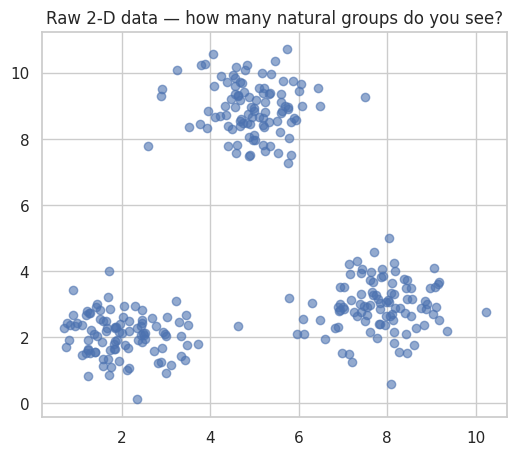

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
blobs = pd.read_csv("../data/blobs_2d.csv")   # we KNOW there are 3 clusters
plt.figure(figsize=(6,5))
plt.scatter(blobs["x1"], blobs["x2"], alpha=0.6)
plt.title("Raw 2-D data — how many natural groups do you see?")
plt.show()

## 10.1 K-Means — the algorithm in plain words

Goal: partition points into **k** clusters so each point is near its cluster's
**centroid** (mean). It minimizes **within-cluster sum of squares** (inertia):

$$ \text{minimize} \sum_{j=1}^{k} \sum_{x \in C_j} \| x - \mu_j \|^2 $$

Iterative recipe (Lloyd's algorithm):
1. Pick k initial centroids (k-means++ does this smartly).
2. **Assign** each point to the nearest centroid.
3. **Update** each centroid to the mean of its assigned points.
4. Repeat 2–3 until assignments stop changing.

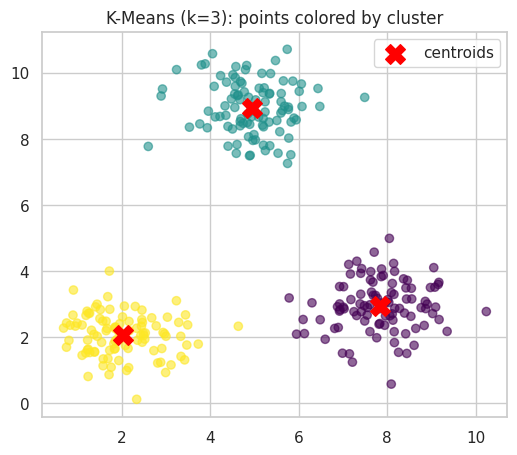

inertia (within-cluster SS): 346.1


In [2]:
X = blobs[["x1", "x2"]].values
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
labels = km.labels_

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", alpha=0.6)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            c="red", s=200, marker="X", label="centroids")
plt.title("K-Means (k=3): points colored by cluster"); plt.legend(); plt.show()
print("inertia (within-cluster SS):", round(km.inertia_, 1))

**K-Means assumptions & failure modes (say these in interviews):**
- Assumes clusters are **roughly spherical and similar size** (uses Euclidean
  distance to a mean). It struggles with elongated/odd shapes or very different
  densities → consider **DBSCAN** or **Gaussian Mixtures** there.
- Sensitive to **initialization** → use `n_init` > 1 (or k-means++).
- You must **choose k** — it won't tell you.
- **Scaling matters**: distance-based, so unscaled large-range features dominate.

## 10.2 Choosing k — the elbow method

Plot inertia vs k. Inertia always falls as k rises (more centroids = tighter
clusters), but the *rate* of improvement drops sharply at the "right" k — the
**elbow**. It's a guide, not gospel.

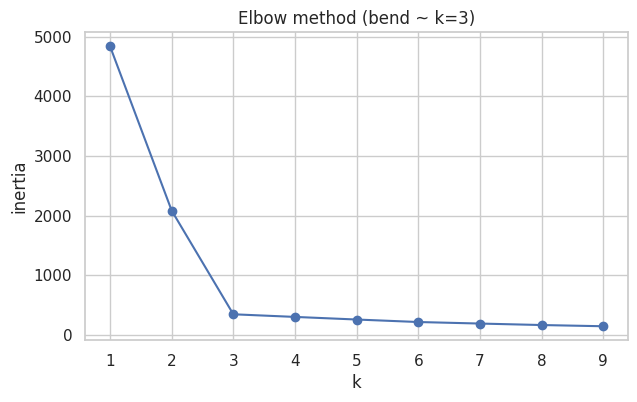

In [3]:
ks = range(1, 10)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_
            for k in ks]
plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, "o-")
plt.xlabel("k"); plt.ylabel("inertia"); plt.title("Elbow method (bend ~ k=3)")
plt.show()

## 10.3 Choosing k — the silhouette score (more rigorous)

For each point, silhouette compares how close it is to its **own** cluster vs the
**nearest other** cluster, giving a value in `[-1, 1]`:
- near **+1**: well inside its cluster (good).
- near **0**: on a boundary.
- **negative**: probably in the wrong cluster.

Average silhouette across all points scores the whole clustering. **This is the
exact metric you improved from 0.32 → 0.717 in your NSE project** — a jump from
"weak, overlapping clusters" to "clearly separated, meaningful clusters".

In [4]:
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    score = silhouette_score(X, km_k.labels_)
    print(f"k={k}: silhouette = {score:.3f}")
print("\nHighest silhouette => best-separated clustering (should favor k=3).")

k=2: silhouette = 0.590
k=3: silhouette = 0.775
k=4: silhouette = 0.619
k=5: silhouette = 0.497
k=6: silhouette = 0.346

Highest silhouette => best-separated clustering (should favor k=3).


### Silhouette plot — diagnose cluster quality visually

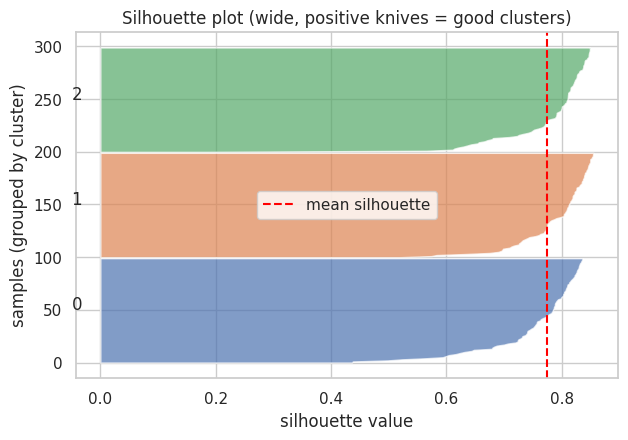

In [5]:
k = 3
km3 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
sv = silhouette_samples(X, km3.labels_)

plt.figure(figsize=(7,4.5))
y_lower = 0
for i in range(k):
    vals = np.sort(sv[km3.labels_ == i])
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    plt.text(-0.05, (y_lower + y_upper)/2, str(i))
    y_lower = y_upper
plt.axvline(silhouette_score(X, km3.labels_), color="red", ls="--",
            label="mean silhouette")
plt.xlabel("silhouette value"); plt.ylabel("samples (grouped by cluster)")
plt.title("Silhouette plot (wide, positive knives = good clusters)")
plt.legend(); plt.show()

## 10.4 The scaling lesson for clustering (real customer data)

Let's cluster our customers by `income` and `support_calls`. Income is in the tens
of thousands; calls are 0–6. **Without scaling**, K-Means "sees" only income and
ignores calls entirely. Scaling fixes it.

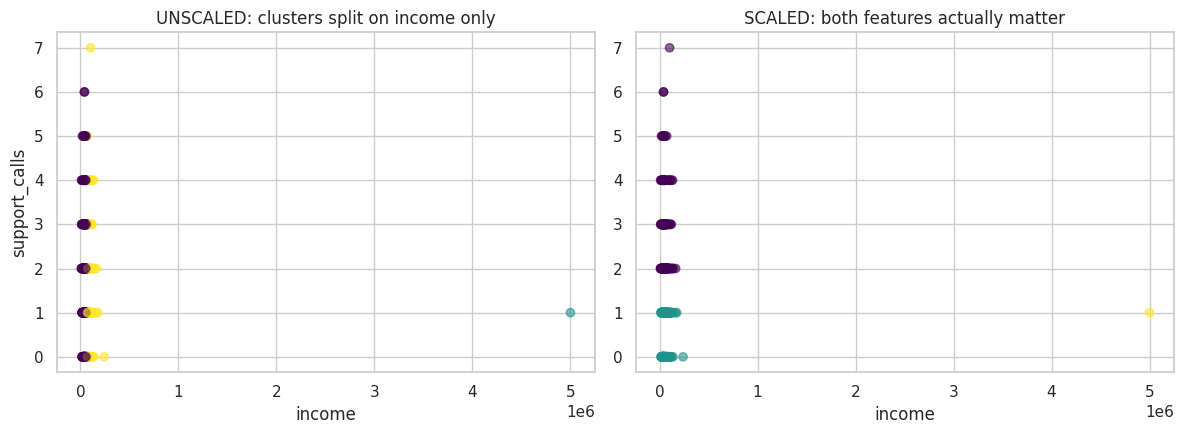

Unscaled silhouette: 0.624 | Scaled silhouette: 0.627


In [6]:
cust = pd.read_csv("../data/customers_clean.csv")
feat = cust[["income", "support_calls"]].dropna().values

# unscaled
lab_raw = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(feat)
# scaled
feat_s = StandardScaler().fit_transform(feat)
lab_scaled = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(feat_s)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(feat[:,0], feat[:,1], c=lab_raw, cmap="viridis", alpha=0.6)
ax[0].set_title("UNSCALED: clusters split on income only"); ax[0].set_xlabel("income"); ax[0].set_ylabel("support_calls")
ax[1].scatter(feat[:,0], feat[:,1], c=lab_scaled, cmap="viridis", alpha=0.6)
ax[1].set_title("SCALED: both features actually matter"); ax[1].set_xlabel("income")
plt.tight_layout(); plt.show()
print("Unscaled silhouette:", round(silhouette_score(feat, lab_raw), 3),
      "| Scaled silhouette:", round(silhouette_score(feat_s, lab_scaled), 3))

## 10.5 PCA — Principal Component Analysis

PCA finds new axes (**principal components**) that are (1) orthogonal and (2)
ordered by how much **variance** they capture. PC1 is the direction of maximum
spread; PC2 the next, perpendicular to PC1; and so on. Mathematically they are the
**eigenvectors of the covariance matrix**, and each component's captured variance
is its **eigenvalue** — right in your linear-algebra wheelhouse.

Uses:
- **Dimensionality reduction**: keep the few components that hold most variance →
  less noise, faster models, fights the curse of dimensionality.
- **Visualization**: project high-dim data to 2-D.
- **Decorrelation**: components are uncorrelated.

**Always scale before PCA** — it's variance-based, so unscaled big features hijack
the components.

explained variance ratio per PC: [0.73  0.229 0.037 0.005]
cumulative: [0.73  0.958 0.995 1.   ]


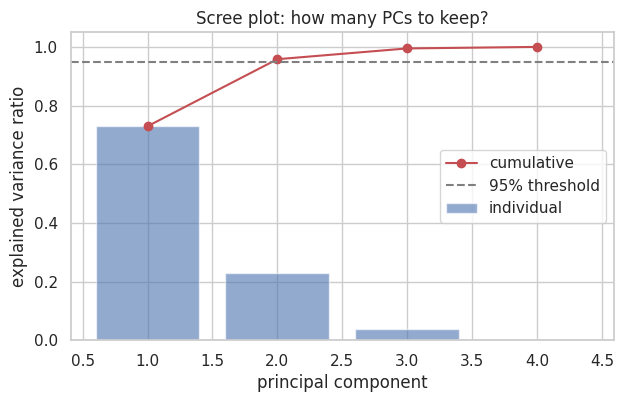

In [7]:
from sklearn.datasets import load_iris
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data)   # 4 features -> scaled

pca = PCA().fit(Xi)
ev = pca.explained_variance_ratio_
print("explained variance ratio per PC:", ev.round(3))
print("cumulative:", ev.cumsum().round(3))

plt.figure(figsize=(7,4))
plt.bar(range(1, len(ev)+1), ev, alpha=0.6, label="individual")
plt.plot(range(1, len(ev)+1), ev.cumsum(), "ro-", label="cumulative")
plt.axhline(0.95, color="gray", ls="--", label="95% threshold")
plt.xlabel("principal component"); plt.ylabel("explained variance ratio")
plt.title("Scree plot: how many PCs to keep?"); plt.legend(); plt.show()

**Reading it:** if the first 2 components already explain ~95% of variance, we can
compress 4 features → 2 with almost no information loss. That's the essence of
dimensionality reduction. The rule of thumb: keep enough PCs to reach a target
cumulative variance (e.g. 90–95%).

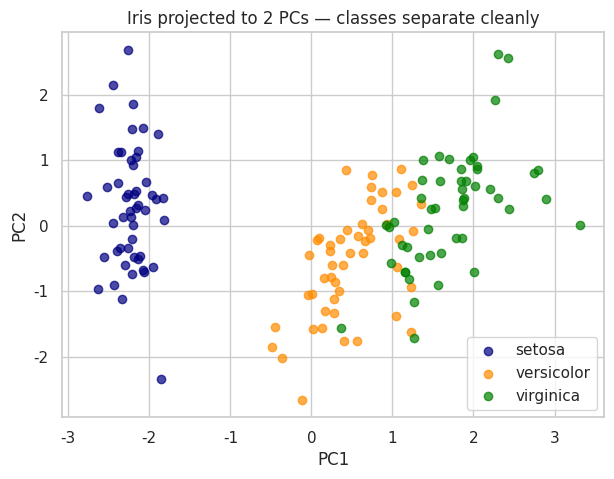

In [8]:
proj = PCA(n_components=2).fit_transform(Xi)
plt.figure(figsize=(7,5))
for cls, name, c in zip(range(3), iris.target_names, ["navy","darkorange","green"]):
    m = iris.target == cls
    plt.scatter(proj[m,0], proj[m,1], label=name, alpha=0.7, color=c)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Iris projected to 2 PCs — classes separate cleanly"); plt.legend()
plt.show()

**Caveat to mention:** PCA components are **linear combinations** of original
features, so they're less interpretable ("PC1 = 0.5·petal_len + 0.4·petal_wid…").
Use PCA when compression/denoising/visualization matters more than per-feature
interpretability.

## 10.6 Mini-exercises

1. Cluster the customers on 4 scaled features; pick k by silhouette; then *profile*
   each cluster (mean of each feature) and give each a business name.
2. Run PCA on those 4 features; how many PCs for 90% variance?
3. Reduce to 2 PCs, then K-Means on the projection — does silhouette improve?
4. Explain why K-Means might fail on two concentric rings, and what you'd use
   instead.

## Summary

- **K-Means** minimizes within-cluster variance; assumes spherical, similar-size
  clusters; needs **scaling** and a chosen **k**.
- Choose k with the **elbow** (inertia bend) and, more rigorously, the
  **silhouette** score — the metric behind your NSE 0.32→0.717 win.
- **PCA** re-expresses data along max-variance orthogonal axes (eigenvectors of
  covariance); keep top PCs for compression/denoising/plots. **Scale first.**
- Trade interpretability for compactness knowingly.

Next: **Module 11 — Neural Networks intro**.